In [220]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
from scipy.spatial.transform import Rotation as R
import seaborn as sns

%matplotlib inline

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [180]:
# Methane potential reference
# Constants
A = np.array([0.262373610e7,  0.265413949e7,  0.241399203e6, -0.271732286e6, -0.749715218e5, 0.123654939e6])
alpha = np.array([0.16878421e1, 0.28827219e1, 0.35917561e1, 0.16490747e1, 0.20593086e1, 0.21451641e1])
b = np.array([0.168275675e1, 0.288261054e1, 0.384703188e1, 0.155011960e1, 0.266424603e1, 0.304993944e1])
C6 = np.array([0.112317356e7, -0.139633537e7, 0.294147230e6, 0.127844394e7, 0.169329268e6,  -0.590727146e6])
C8 = np.array([-0.120939119e9, 0.385078060e8,  -0.264781786e7, 0.174762764e7,  -0.810401688e7, 0.679543866e7])
qH = 0.94753e2
qC = -0.379012e3
b_corr = 0.177e1
delta_C6 = 0.45347e5
delta_C8 = 0.432463e6

num_sites = 9

def calc_potential(r, A, b, alpha, C6, C8, q1, q2):
    expTerm = A * np.exp(-alpha * r)
    f6 = 1.0 - np.exp(-b*r) * (1.0 + (b*r) + ((b*r)**2) / 2. + ((b*r)**3) / 6. + ((b*r)**4) / 24. + ((b*r)**5) / 120. + ((b*r)**6) / 720.)
    f8 = f6 - np.exp(-b*r) * (((b*r)**7) / 5040. + ((b*r)**8) / 40320.)
    return expTerm - (C6 / (r**6)) * f6 - (C8 / (r**8)) * f8 + q1 * q2 / r

def calc_potential_correction(r, b_corr, delta_C6, delta_C8):
    f6 = 1.0 - np.exp(-b_corr*r) * (1.0 + (b_corr*r) + ((b_corr*r)**2) / 2. + ((b_corr*r)**3) / 6. + ((b_corr*r)**4) / 24. + ((b_corr*r)**5) / 120. + ((b_corr*r)**6) / 720.)
    f8 = f6 - np.exp(-b_corr*r) * (((b_corr*r)**7) / 5040. + ((b_corr*r)**8) / 40320.)
    return - (delta_C6 / (r**6)) * f6 - (delta_C8 / (r**8)) * f8

def make_tetra_sites1(factor):
    dist_CH = 1.099
    site_dist = factor * dist_CH
    site_positions = np.array([[-site_dist, 0.0, 0.0],
                              [site_dist / 3., site_dist * (2.* np.sqrt(2.) / 3.), 0.0],
                              [site_dist / 3., - site_dist * np.sqrt(2.) / 3., site_dist * np.sqrt(6.) / 3.],
                              [site_dist / 3., - site_dist * np.sqrt(2.) / 3., - site_dist * np.sqrt(6.) / 3.]])
    return site_positions

def make_tetra_sites(factor):
    inv_sqrt3 = 1. / np.sqrt(3.0)
    dist_CH = 1.099
    site_dist = factor * dist_CH * inv_sqrt3
    site_positions = np.array([[site_dist, site_dist, site_dist],
                              [site_dist, -site_dist, -site_dist],
                              [-site_dist, site_dist, -site_dist],
                              [-site_dist, -site_dist, site_dist]])
    return site_positions


def distance(pos1, pos2):
    return np.linalg.norm(pos2 - pos1)


pos1 = np.vstack((np.array([[0.0, 0.0, 0.0]]), make_tetra_sites1(0.88), make_tetra_sites1(-0.66)))

rotation_180z = R.from_euler('z', 180., degrees=True)
pos2 = rotation_180z.apply(pos1)

rotation_half109leftz = R.from_euler('z', -54.75, degrees=True)
pos3 = rotation_half109leftz.apply(pos1)

rotation_half109rightz = R.from_euler('z', 125.25, degrees=True)
pos4 = rotation_half109rightz.apply(pos1)


sites_P1 = pos1
dx = 0.001
dists_ref = np.arange(2.5, 8.5, dx)

pot_energy = np.zeros_like(dists_ref)
pot_energy_corrected = np.zeros_like(dists_ref)
for idx, shift in enumerate(dists_ref):
    
    sites_P2 = pos2 + np.array([shift, 0.0, 0.0])
    pot_sum = 0.0
    
    # C-C
    pot_sum += calc_potential(distance(sites_P1[0], sites_P2[0]), A[0], b[0], alpha[0], C6[0], C8[0], qC, qC)
    # C-H
    for i in range(4):
        pot_sum += calc_potential(distance(sites_P1[0], sites_P2[1+i]), A[1], b[1], alpha[1], C6[1], C8[1], qC, qH)
        pot_sum += calc_potential(distance(sites_P1[1+i], sites_P2[0]), A[1], b[1], alpha[1], C6[1], C8[1], qC, qH)
    # H-H
    for i in range(4):
        for j in range(4):
            pot_sum += calc_potential(distance(sites_P1[1+i], sites_P2[1+j]), A[2], b[2], alpha[2], C6[2], C8[2], qH, qH)
    # C-E
    for i in range(4):
        pot_sum += calc_potential(distance(sites_P1[0], sites_P2[5+i]), A[3], b[3], alpha[3], C6[3], C8[3], qC, 0.0)
        pot_sum += calc_potential(distance(sites_P1[5+i], sites_P2[0]), A[3], b[3], alpha[3], C6[3], C8[3], qC, 0.0)
    # H-E
    for i in range(4):
        for j in range(4):
            pot_sum += calc_potential(distance(sites_P1[1+i], sites_P2[5+j]), A[4], b[4], alpha[4], C6[4], C8[4], qH, 0.0)
            pot_sum += calc_potential(distance(sites_P1[5+i], sites_P2[1+j]), A[4], b[4], alpha[4], C6[4], C8[4], qH, 0.0)
    # E-E
    for i in range(4):
        for j in range(4):
            pot_sum += calc_potential(distance(sites_P1[5+i], sites_P2[5+j]), A[5], b[5], alpha[5], C6[5], C8[5], 0.0, 0.0)
            
    pot_energy[idx] = pot_sum
    # pot_energy_corrected[idx] = pot_sum + calc_potential_correction(distance(sites_P1[0], sites_P2[0]), b_corr, delta_C6, delta_C8)
    
force = - np.gradient(pot_energy, dx)

In [42]:
paper_dists = np.array([2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0, 5.5, 6.0, 6.5, 7.0, 8.0])
paper_energy_fit = np.array([8155.60, 2777.63, 676.192, -58.840, -257.529, -265.580, -218.941, -166.389, -122.429, -89.205, -65.108, -35.580, -20.332, -12.152, -7.570, -3.276])
paper_energy_abinitio = np.array([7843.67, 2727.14, 678.222, -52.924, -255.262, -266.072, -220.489, -167.941, -123.586, -89.924, -65.510, -35.669, -20.375, -12.218, -7.645, -3.323])

indices = [np.abs(dists_ref - v).argmin() for v in paper_dists]
diff_to_paper = paper_energy_fit - pot_energy[indices]
print(diff_to_paper)

max_well_depth_paper = 273.9 # Kelvin
max_well_distance_paper = 3.633 # Angstöm
max_well_depth_notebook = np.min(pot_energy_corrected)
max_well_distance_notebook = dists_ref[np.argmin(pot_energy_corrected)]
print("Maximum well depth of {} K at {} A".format(max_well_depth_notebook, max_well_distance_notebook))

[-4.76407423e-03 -4.40844225e-04 -1.14325079e-03 -8.75990154e-04
 -3.71555832e-04 -1.93915918e-06 -5.49360628e-04  1.35050493e-05
 -6.29114238e-05 -1.32840350e-04 -3.52112373e-04 -2.80569792e-04
 -2.09220860e-04 -5.89500557e-05  2.76585947e-04  2.38393528e-04]
Maximum well depth of 0.0 K at 2.5 A


In [43]:
filename = "methane-2b-linear"
folder = "cmake-build-debug"

path = folder + "/" + filename + ".csv"

In [44]:
df = pd.read_csv(path)

In [45]:
df["Force Mag"] = -1.0 * np.sign(df["Force_x [K/A]"]) * np.linalg.norm(df[['Force_x [K/A]', 'Force_y [K/A]', 'Force_z [K/A]']].values, axis=1)
df.head()

,Distance [A],Energy [K],Force_x [K/A],Force_y [K/A],Force_z [K/A],Force Mag
0,2.50,8155.604764,-32554.821679,1.345340e-10,-2.270000e-13,32554.821679
1,2.51,7835.704551,-31431.335395,-4.814600e-11,-1.280000e-13,31431.335395
2,2.52,7526.857633,-30343.977016,2.515000e-12,-4.550000e-13,30343.977016
3,2.53,7228.708249,-29291.648217,1.420000e-13,4.260000e-13,29291.648217
4,2.54,6940.911463,-28273.282195,3.141000e-12,1.850000e-13,28273.282195


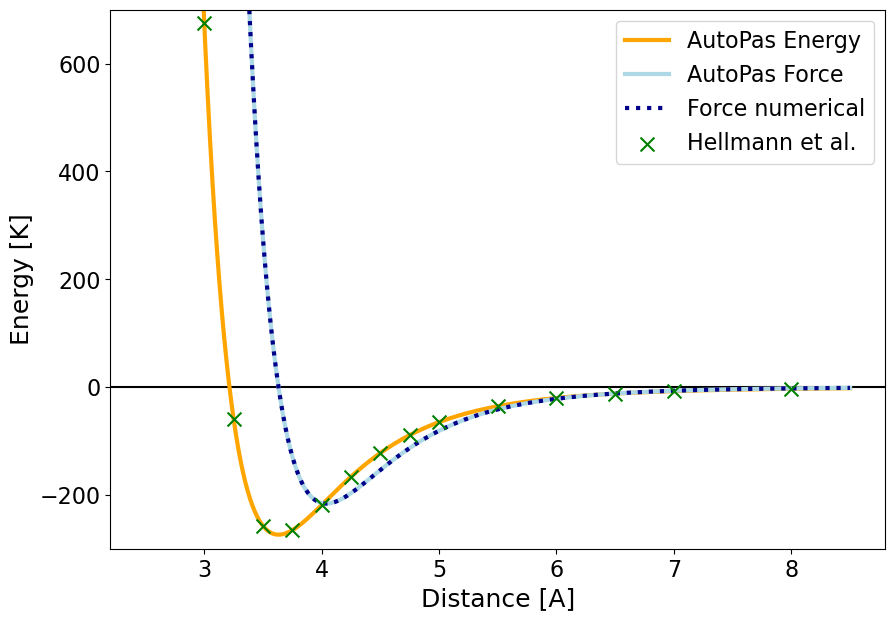

In [59]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.axhline(y=0.0, color='k', linestyle='-')

# ax.plot(dists_ref, pot_energy_corrected, label="notebook energy", linewidth=3)
ax.plot(df["Distance [A]"], df["Energy [K]"], label="AutoPas Energy", linestyle='-', linewidth=3, color="orange")
ax.plot(df["Distance [A]"], df["Force Mag"], label="AutoPas Force", linestyle='-', linewidth=3, color="lightblue")
ax.plot(dists_ref, force, label="Force numerical", linewidth=3, linestyle=":", color="darkblue")

ax.scatter(paper_dists, paper_energy_fit, label="Hellmann et al.", s=100, color="green", zorder=5, marker='x')
# ax.scatter(paper_dists, paper_energy_abinitio, label="Orientation 1", s=100, marker='x')

ax.set_ylabel("Energy [K]", fontsize=18)
ax.set_xlabel("Distance [A]", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_ylim(-300, 700)
ax.legend(fontsize=16)

plt.show()

In [200]:
num_threads = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024])
# All LC traversals
runtimes = np.array([0, 3267.39, 1652.14, 836.544, 625.787, 360.148, 238.335, 145.18, 374.595, 0, 0])
# Only LCC01
runtimes_c01 = np.array([488.575, 374.542, 0, 146.322])

# Rebuild = 1
runtimes_rebuild = np.array([6600, 3266.28, 1651.14, 834.24, 451.813, 288.271, 174.131, 100.834, 65.5913, 37.4606, 27.4794])
ref = 3266.28
runtimes_perfect = np.pow(2.0, np.arange(1,-10, -1)) * ref
speedup = runtimes_rebuild[1] / runtimes_rebuild

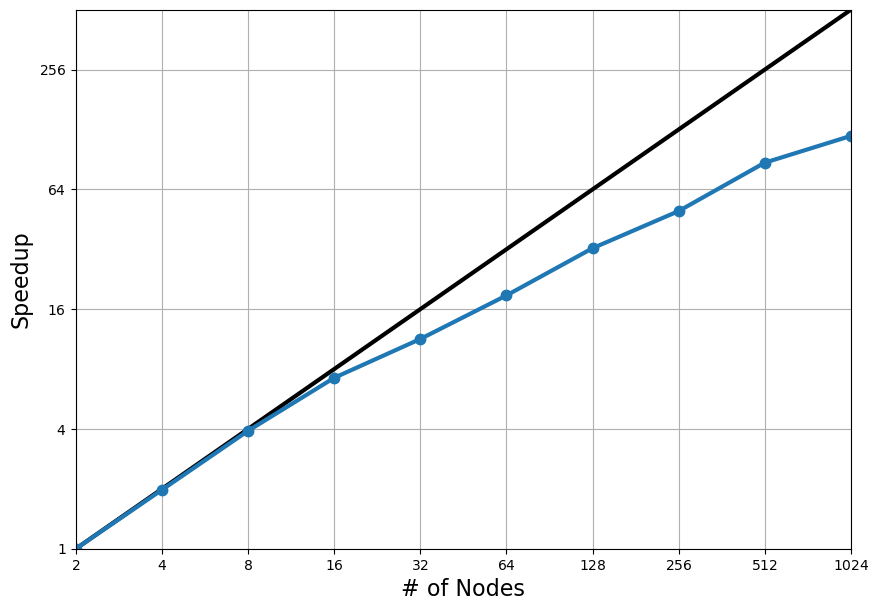

In [227]:
fig_scaling, ax = plt.subplots(figsize=(10, 7))


# ax.plot(num_threads, runtimes)
# ax.plot(num_threads, runtimes_rebuild)
# ax.plot(num_threads, runtimes_perfect)

ax.plot(num_threads, num_threads * 0.5, color='black', linewidth=3)
ax.plot(num_threads, speedup, marker='.', linewidth=3, markersize=15)

ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
ax.set_xticks([1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024])
ax.set_xlim(2, 1024)
ax.set_ylim(1, 512)
ax.set_xlabel('# of Nodes', fontsize=16)
ax.set_ylabel('Speedup', fontsize=16)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))

ax.grid()
plt.show()

In [ ]:
#SBATCH --mail-type=end
#SBATCH --mail-user=markus.muehlhaeusser@tum.de
#SBATCH --export=NONE
#SBATCH --time=00:15:00
#SBATCH --account=pn67ku
#SBATCH --partition=general

source /etc/profile.d/modules.sh

module load slurm_setup
# module load intel-toolkit
# module load lrztools/3.0
# module list
module unload intel-mpi
module load gcc/14.2.0
module load intel-mpi/2021-gcc

cd $HOME
cd jobs/

export OMP_NUM_THREADS=48
# $SLURM_CPUS_PER_TASK
# mpiexec -n $SLURM_NTASKS placementtest-mpi.intel

mpiexec -n $SLURM_NTASKS ../ls1-mardyn/build-supermuc/src/MarDyn ./config_autopas_soa_3b.xml --final-checkpoint=0

exit $?



In [ ]:
#!/bin/bash -l
#SBATCH -J 3xa-scaling-512
#SBATCH -o ./%x.%j.out
#SBATCH --get-user-env
#SBATCH --nodes=512
#SBATCH --ntasks-per-node=1
#SBATCH --cpus-per-task=48
#SBATCH --mail-type=end
#SBATCH --mail-user=markus.muehlhaeusser@tum.de
#SBATCH --export=NONE
#SBATCH --time=00:10:00
#SBATCH --account=pn67ku
#SBATCH --partition=general


In [191]:
#!/bin/bash -l
#SBATCH -J 3xa-scaling-128
#SBATCH -o ./%j.%x.out
#SBATCH --get-user-env
#SBATCH --nodes=128
#SBATCH --ntasks-per-node=1
#SBATCH --cpus-per-task=48
#SBATCH --mail-type=end
#SBATCH --mail-user=markus.muehlhaeusser@tum.de
#SBATCH --export=NONE
#SBATCH --time=00:15:00
#SBATCH --account=pn67ku
#SBATCH --partition=general
np.set_printoptions(linewidth=120)
pd.set_option('display.width', 500)
pd.options.display.max_colwidth = 200


LJFunctorAutoVec-LinkedCells-lc_c08-SoA-enabled-1.0
AxilrodTellerMutoFunctorAutoVec-LinkedCells-lc_c08-SoA-enabled-1.0


<Figure size 1200x600 with 0 Axes>

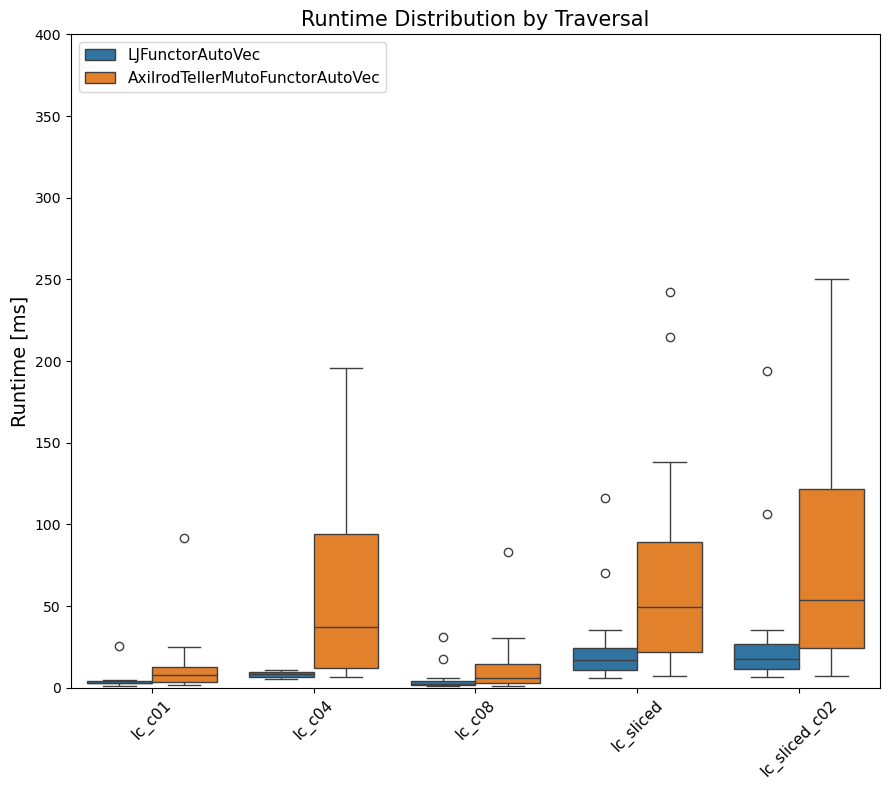

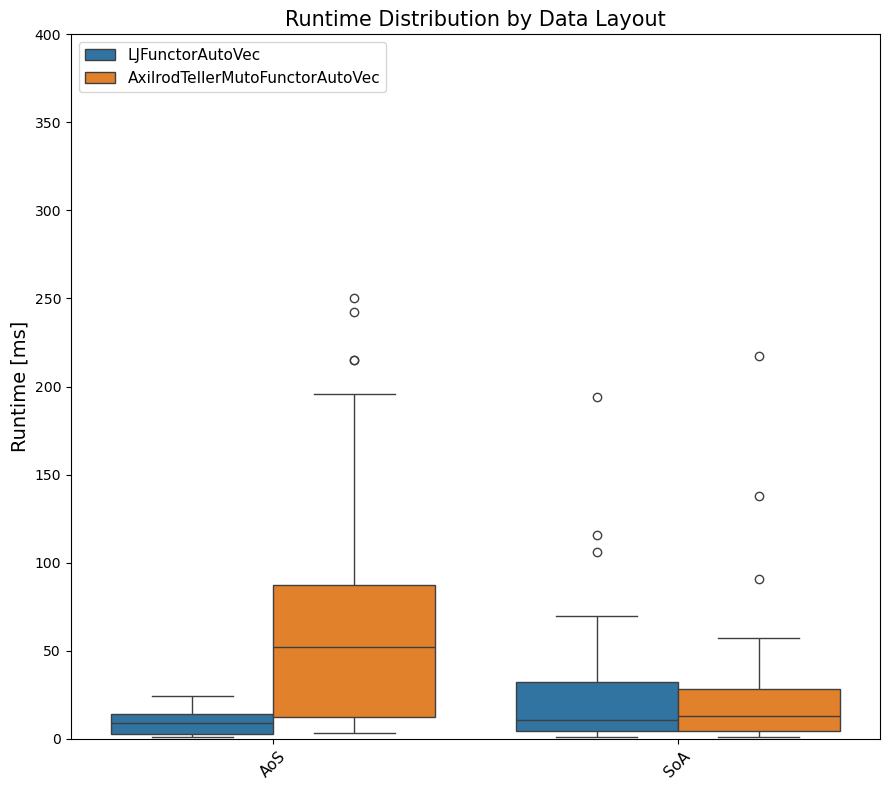

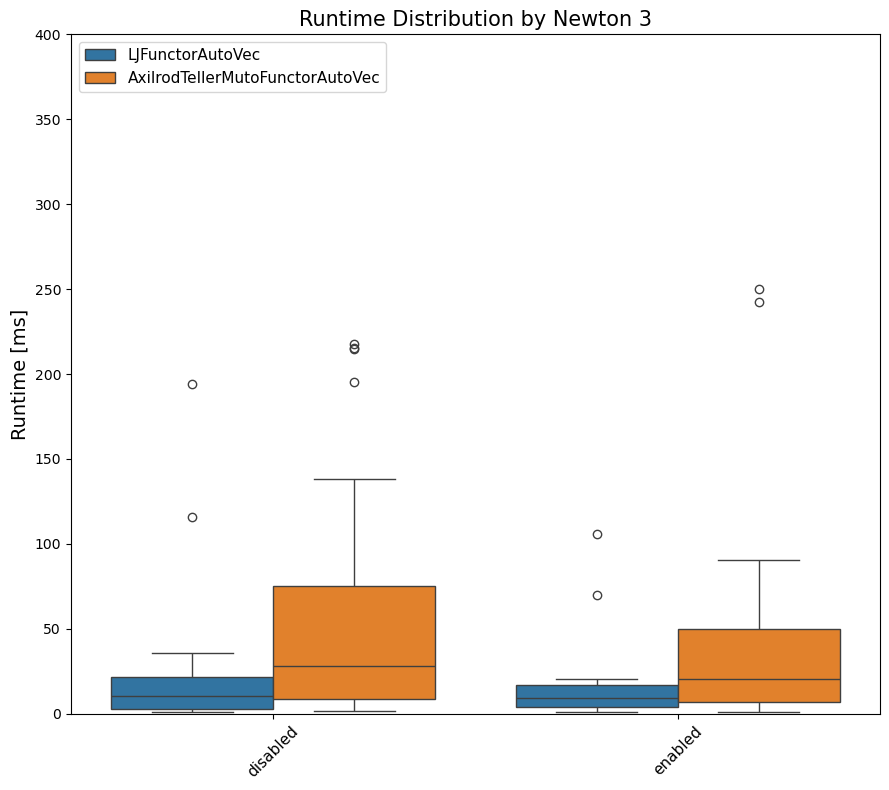

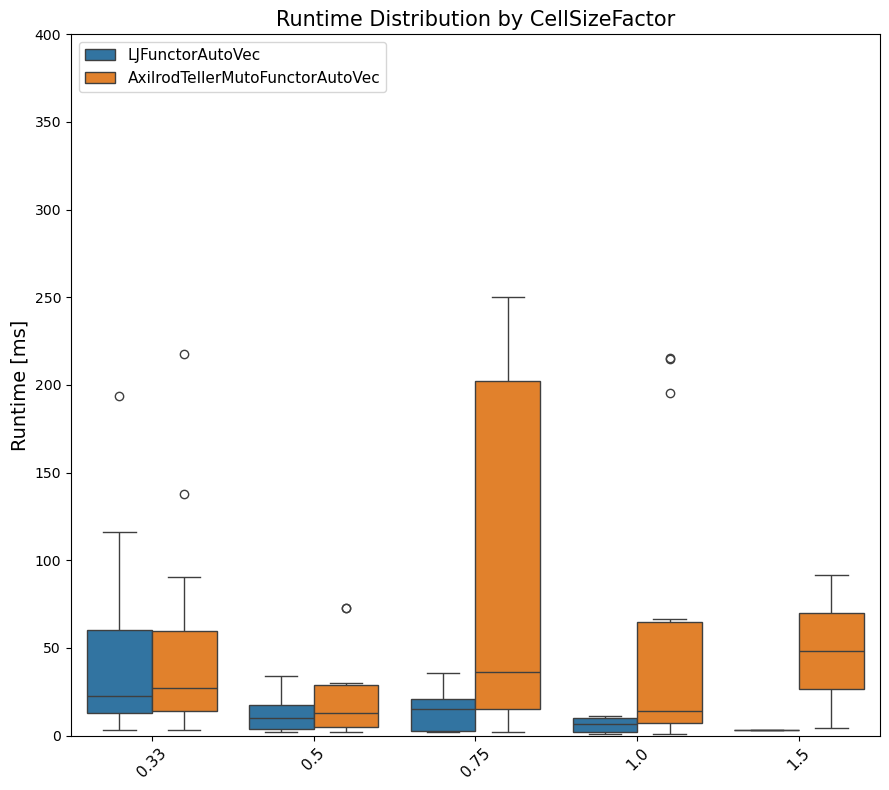

                                             ConfigLabel  computeInteractions[ms]
29   LJFunctorAutoVec-LinkedCells-lc_c08-SoA-enabled-1.0                 2.449311
21   LJFunctorAutoVec-LinkedCells-lc_c08-AoS-enabled-1.0                 2.858313
8   LJFunctorAutoVec-LinkedCells-lc_c01-SoA-disabled-1.0                 2.943576
25  LJFunctorAutoVec-LinkedCells-lc_c08-SoA-disabled-1.0                 3.899127
17  LJFunctorAutoVec-LinkedCells-lc_c08-AoS-disabled-1.0                 4.138556
                                                            ConfigLabel  computeInteractions[ms]
29   AxilrodTellerMutoFunctorAutoVec-LinkedCells-lc_c08-SoA-enabled-1.0                81.298656
8   AxilrodTellerMutoFunctorAutoVec-LinkedCells-lc_c01-SoA-disabled-1.0               128.852539
27   AxilrodTellerMutoFunctorAutoVec-LinkedCells-lc_c08-SoA-enabled-0.5               141.597854
25  AxilrodTellerMutoFunctorAutoVec-LinkedCells-lc_c08-SoA-disabled-1.0               167.229279
28  AxilrodTellerMutoFu

In [242]:
# Load your CSV file (make sure to update 'paste.txt' to your actual path)
df = pd.read_csv('AutoPas_IterationLog_LCComparison_1p0Spacing.csv')
# df = pd.read_csv('AutoPas_IterationLog_LCComparison_1p2Spacing.csv')
# df = pd.read_csv('AutoPas_IterationLog_LCComparison_1p4Spacing.csv')

df = df.drop('Date', axis=1)
df = df.drop('Interaction Type', axis=1)
df = df.drop('Load Estimator', axis=1)
df['computeInteractions[ms]'] = df['computeInteractions[ns]'] / 1.0e6
# Example visualization: Compare computeInteractionsTotal[ns] for each Functor
plt.figure(figsize=(12,6))
df_LJ = df[df['Functor'] == "LJFunctorAutoVec"]
df_ATM = df[df['Functor'] == "AxilrodTellerMutoFunctorAutoVec"]

# Identify columns that define a configuration (non-numerical)
config_columns = ['Functor', 'Container', 'Traversal', 'Data Layout', 'Newton 3', 'CellSizeFactor']
num_columns = ['computeInteractions[ns]', 'remainderTraversal[ns]', 'rebuildNeighborLists[ns]', 'computeInteractionsTotal[ns]', 'tuning[ns]']
ref_config = {
    'Traversal': 'lc_c01',
    'CellSizeFactor': 1.00,
    'Data Layout': 'AoS',
    'Newton 3': 'disabled'
}
# Group by configuration columns and average numerical columns
df_lj_avg = df_LJ.groupby(config_columns, as_index=False).mean()
df_lj_avg['ConfigLabel'] = df_lj_avg[config_columns].astype(str).agg('-'.join, axis=1)

ref_row = df_lj_avg[df_lj_avg['computeInteractions[ns]'] == df_lj_avg['computeInteractions[ns]'].min()].iloc[0]
print(ref_row['ConfigLabel'])
# Extract reference values as a Series
df_lj_normalized = df_lj_avg.copy()
for col in num_columns:
    df_lj_normalized[col] = df_lj_normalized[col].div(ref_row[col])

df_atm_avg = df_ATM.groupby(config_columns, as_index=False).mean()
df_atm_avg['ConfigLabel'] = df_atm_avg[config_columns].astype(str).agg('-'.join, axis=1)

ref_row = df_atm_avg[df_atm_avg['computeInteractions[ns]'] == df_atm_avg['computeInteractions[ns]'].min()].iloc[0]
print(ref_row['ConfigLabel'])
# Extract reference values as a Series
df_atm_normalized = df_atm_avg.copy()
for col in num_columns:
    df_atm_normalized[col] = df_atm_normalized[col].div(ref_row[col])

df_avg = df.groupby(config_columns, as_index=False).mean()
df_normalized = pd.concat([df_lj_normalized, df_atm_normalized])

# Plot runtime distributions for each categorical parameter
parameter_columns = ['Traversal', 'Data Layout', 'Newton 3', 'CellSizeFactor']
for cat in parameter_columns:
    plt.figure(figsize=(9,8))
    sns.boxplot(x=cat, y='computeInteractions[ns]', hue='Functor', data=df_normalized)
    # sns.boxplot(x=cat, y='computeInteractions[ms]', data=df_atm_avg)
    plt.title(f'Runtime Distribution by {cat}', fontsize=15)
    plt.xticks(rotation=45, fontsize=11)
    plt.xlabel('')
    plt.ylabel('Runtime [ms]', fontsize=14)
    plt.ylim(0, 400)
    plt.tight_layout()
    plt.legend(loc='upper left', fontsize=11)
    plt.show()

print(df_lj_avg.nsmallest(5, 'computeInteractions[ms]')[['ConfigLabel', 'computeInteractions[ms]']])
print(df_atm_avg.nsmallest(5, 'computeInteractions[ms]')[['ConfigLabel', 'computeInteractions[ms]']])

# for i, label in enumerate(df_lj_avg['ConfigLabel']):
#     plt.annotate(label, (i, df_lj_avg.iloc[i]['computeInteractionsTotal[ns]']), fontsize=8, rotation=45, ha='right')
    
# plt.bar(df_lj_avg['ConfigLabel'], df_lj_avg['computeInteractions[ns]'])
# plt.ylim(0, 1.0e8)
# plt.xlabel('Configuration')
# plt.ylabel('computeInteractionsTotal [ns]')
# plt.title('Interaction Time per Iteration by Functor')
# plt.legend()
# plt.tight_layout()
# plt.show()

# # Example: Scatter plot between cell size factor and computeInteractionsTotal for pairwise vs triwise
# plt.figure(figsize=(12,6))

# plt.bar(df_atm_avg['ConfigLabel'], df_atm_avg['computeInteractions[ns]'])

# plt.ylim(0, 0.2e11)
# plt.xlabel('Configuration')
# plt.ylabel('computeInteractionsTotal [ns]')
# plt.title('Cell Size Factor vs Interaction Time')
# plt.legend()
# plt.tight_layout()
# plt.show()
